In [ ]:
import pandas as pd
import sklearn 
from sklearn.metrics  import accuracy_score
from sklearn.mode_selection import train_test_split

In [16]:
!pip install kagglehub

In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rahuljangir78/esg-and-financial-metrics-of-manufacturing-firms")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\bhati\.cache\kagglehub\datasets\rahuljangir78\esg-and-financial-metrics-of-manufacturing-firms\versions\1


In [18]:
df = pd.read_csv(r"C:\Users\bhati\Downloads\Manufacturing_ESG_Financial_Data.csv")

In [19]:
env_df = df[["Firm_ID","Year","E_Score","Revenue"]]

In [20]:
env_df = env_df.fillna(env_df.mean(numeric_only=True))

In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
env_df["E_Score_Normalized"] = scaler.fit_transform(
    env_df[["E_Score"]]
)

In [23]:
env__df=env_df.sort_values(["Firm_ID","Year"]
)

In [24]:
env_df["E_change"]=env_df.groupby("Firm_ID")["E_Score_Normalized"].diff()

In [25]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05)
env_df["env_anomaly"] = iso.fit_predict(
    env_df[["E_Score_Normalized"]]
)

In [26]:
env_df

,Firm_ID,Year,E_Score,Revenue,E_Score_Normalized,E_change,env_anomaly
0,MFG0103,2023,71.37,207.77,0.481563,NaN,1
1,MFG0436,2021,85.20,235.40,0.651549,NaN,1
2,MFG0349,2023,75.20,226.76,0.528638,NaN,1
3,MFG0271,2021,100.79,432.06,0.843166,NaN,-1
4,MFG0107,2019,55.59,164.27,0.287611,NaN,1
...,...,...,...,...,...,...,...
4995,MFG0401,2021,83.65,326.47,0.632498,-0.072394,1
4996,MFG0233,2019,72.79,196.14,0.499017,-0.092920,1
4997,MFG0158,2020,86.66,347.81,0.669494,0.266593,1
4998,MFG0437,2022,79.76,332.13,0.584685,0.367994,1


In [27]:
AGENT1_output = df[[
    "Firm_ID",
    "Year",
    "E_Score",
    "Revenue", 
]]

In [28]:
AGENT1_output

,Firm_ID,Year,E_Score,Revenue
0,MFG0103,2023,71.37,207.77
1,MFG0436,2021,85.20,235.40
2,MFG0349,2023,75.20,226.76
3,MFG0271,2021,100.79,432.06
4,MFG0107,2019,55.59,164.27
...,...,...,...,...
4995,MFG0401,2021,83.65,326.47
4996,MFG0233,2019,72.79,196.14
4997,MFG0158,2020,86.66,347.81
4998,MFG0437,2022,79.76,332.13


In [29]:
AGENT1_output.to_csv("ESG1_Output.csv", index=False)

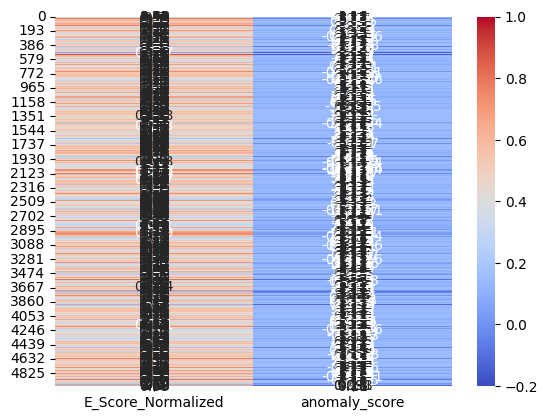

In [ ]:
AGENT1_json = AGENT1_output.to_json(orient="records")
import seaborn as sns
import matplotlib.pyplot as plt




[{"Firm_ID":"MFG0103","Year":2023,"E_Score":71.37,"Revenue":207.77},{"Firm_ID":"MFG0436","Year":2021,"E_Score":85.2,"Revenue":235.4},{"Firm_ID":"MFG0349","Year":2023,"E_Score":75.2,"Revenue":226.76},{"Firm_ID":"MFG0271","Year":2021,"E_Score":100.79,"Revenue":432.06},{"Firm_ID":"MFG0107","Year":2019,"E_Score":55.59,"Revenue":164.27},{"Firm_ID":"MFG0072","Year":2019,"E_Score":73.33,"Revenue":331.39},{"Firm_ID":"MFG0189","Year":2019,"E_Score":67.1,"Revenue":172.6},{"Firm_ID":"MFG0021","Year":2020,"E_Score":74.58,"Revenue":349.6},{"Firm_ID":"MFG0103","Year":2020,"E_Score":91.27,"Revenue":261.78},{"Firm_ID":"MFG0122","Year":2022,"E_Score":91.96,"Revenue":187.8},{"Firm_ID":"MFG0467","Year":2022,"E_Score":72.6,"Revenue":244.19},{"Firm_ID":"MFG0215","Year":2022,"E_Score":81.48,"Revenue":350.05},{"Firm_ID":"MFG0331","Year":2020,"E_Score":74.37,"Revenue":137.21},{"Firm_ID":"MFG0459","Year":2020,"E_Score":60.17,"Revenue":237.24},{"Firm_ID":"MFG0088","Year":2022,"E_Score":72.16,"Revenue":281.29},{

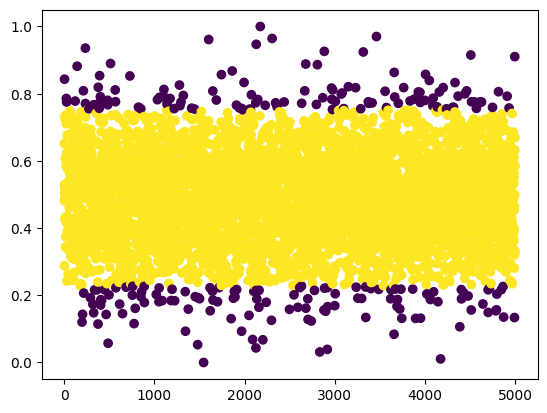

In [38]:
print(AGENT1_json)
env_df["anomaly_score"] = iso.decision_function(
    env_df[["E_Score_Normalized"]]
)
print(env_df["env_anomaly"].value_counts())
import matplotlib.pyplot as plt


plt.scatter(env_df.index, env_df["E_Score_Normalized"],
            c=env_df["env_anomaly"])
print(env_df[["E_Score_Normalized", "env_anomaly", "anomaly_score"]])
